In [1]:
pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "Patient has fever and cough",
    "The person is suffering from flu",
    "Stock market crashed today"
]

embeddings = model.encode(sentences)

similarity = util.cos_sim(embeddings, embeddings)
print(similarity)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tensor([[1.0000, 0.6153, 0.0798],
        [0.6153, 1.0000, 0.0975],
        [0.0798, 0.0975, 1.0000]])


In [3]:
similarity = util.cos_sim(embeddings, embeddings)
print(similarity)

tensor([[1.0000, 0.6153, 0.0798],
        [0.6153, 1.0000, 0.0975],
        [0.0798, 0.0975, 1.0000]])


In [7]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.9 MB/s eta 0:00:00


In [8]:

import gensim.downloader as api

# Load a small pretrained word2vec model from gensim-data
# We'll use "glove-wiki-gigaword-50" (50d vectors, ~70MB) for lightweight demo
model = api.load("glove-wiki-gigaword-50")

# Pick a demo word
word = "king"

# Get vector
vector = model[word]

# Get most similar words
similar = model.most_similar(word, topn=5)

vector[:10], similar  # show first 10 values of vector for brevity, plus top 5 similar words


[==================================================] 100.0% 66.0/66.0MB downloaded


(array([ 0.50451 ,  0.68607 , -0.59517 , -0.022801,  0.60046 , -0.13498 ,
        -0.08813 ,  0.47377 , -0.61798 , -0.31012 ], dtype=float32),
 [('prince', 0.8236179351806641),
  ('queen', 0.7839043140411377),
  ('ii', 0.7746230363845825),
  ('emperor', 0.7736247777938843),
  ('son', 0.766719400882721)])

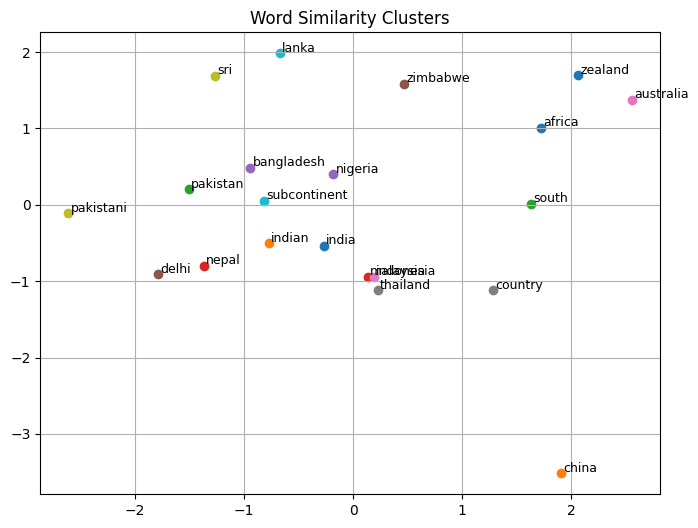

In [18]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load model
model = api.load("glove-wiki-gigaword-50")

# Target word
word = "india"

# Get similar words
similar_words = [w for w, _ in model.most_similar(word, topn=20)]

# Include original word
words = [word] + similar_words

# Get vectors
vectors = np.array([model[w] for w in words])

# Reduce to 2D for plotting
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Cluster into 2 groups
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(coords)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.02, y+0.02, word, fontsize=9)

plt.title("Word Similarity Clusters")
plt.grid(True)
plt.show()

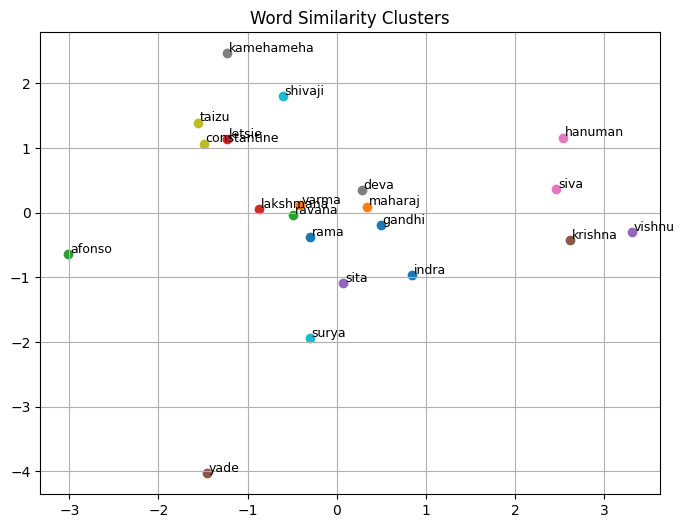

In [16]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load model
model = api.load("glove-wiki-gigaword-50")

# Target word
word = "india"

# Get similar words
similar_words = [w for w, _ in model.most_similar(word, topn=20)]

# Include original word
words = [word] + similar_words

# Get vectors
vectors = np.array([model[w] for w in words])

# Reduce to 2D for plotting
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Cluster into 2 groups
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(coords)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.02, y+0.02, word, fontsize=9)

plt.title("Word Similarity Clusters")
plt.grid(True)
plt.show()

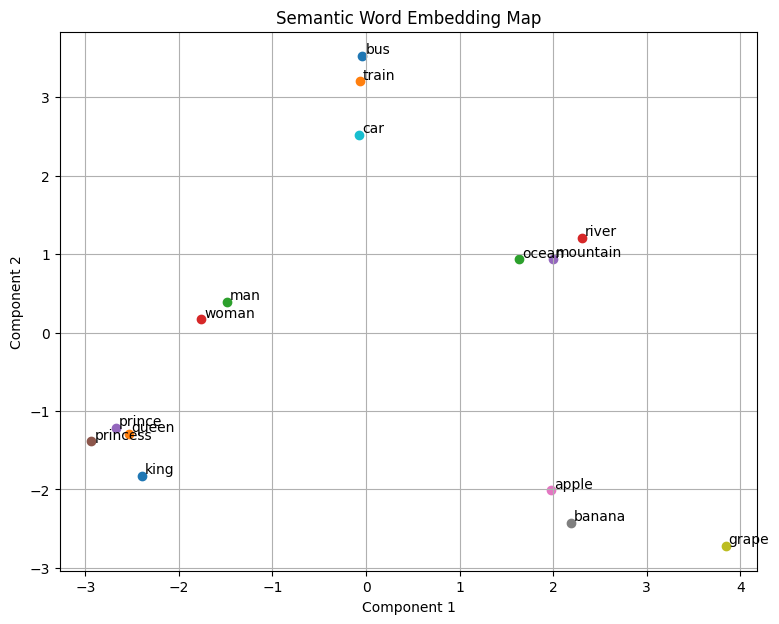

In [15]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load pretrained embeddings
model = api.load("glove-wiki-gigaword-50")

# Words you want to visualize
words = [
    "king","queen","man","woman","prince","princess",
    "apple","banana","grape",
    "car","bus","train",
    "ocean","river","mountain"
]

# Keep only words present in vocab
words = [w for w in words if w in model]

# Get vectors
vectors = np.array([model[w] for w in words])

# Reduce dimensions to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(9,7))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.03, y+0.03, word, fontsize=10)

plt.title("Semantic Word Embedding Map")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


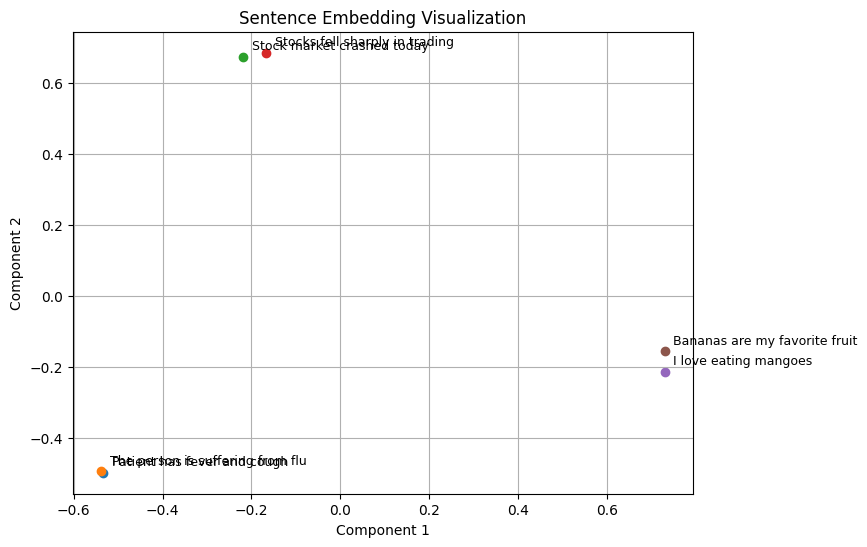

In [17]:
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Sentences
sentences = [
    "Patient has fever and cough",
    "The person is suffering from flu",
    "Stock market crashed today",
    "Stocks fell sharply in trading",
    "I love eating mangoes",
    "Bananas are my favorite fruit"
]

# Generate embeddings
embeddings = model.encode(sentences)

# Reduce dimensions to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))

for i, sentence in enumerate(sentences):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.02, y+0.02, sentence, fontsize=9)

plt.title("Sentence Embedding Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()